In [16]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

### 1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

### 2. Преобразуйте признак Sex в числовой: значение F должно перейти в -1, I — в 0, M — в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x ==’M’ else (-1 if x == ’F’ else 0))

### 3. Разделите содержимое файлов на признаки и целевую переменную. В последнем столбце записана целевая переменная, в остальных — признаки.

In [17]:
data = pd.read_csv('abalone.csv')
data['Sex'] = data['Sex'].map(lambda value: 1 if value == 'M' else (-1 if value == 'F' else 0))
features = data.iloc[:, :-1].values
target = data.iloc[:, -1].values

### 4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor) с различным числом деревьев: от 1 до 50 (random_state=1). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

### 5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это количество и будет ответом на задание.

In [18]:
kfold_splitter = KFold(n_splits=5, shuffle=True, random_state=1)

In [19]:
optimal_estimators = None
for num_trees in range(1, 51):
    forest_model = RandomForestRegressor(n_estimators=num_trees, random_state=1)
    r2_scores = cross_val_score(forest_model, features, target, cv=kfold_splitter, scoring='r2')
    average_r2 = np.mean(r2_scores)
    
    if average_r2 > 0.52:
        optimal_estimators = num_trees
        break

In [20]:
print(f"Ответ: {optimal_estimators}")
with open('ans.txt', 'w') as output_file:
    output_file.write(str(optimal_estimators))

Ответ: 21


### 6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

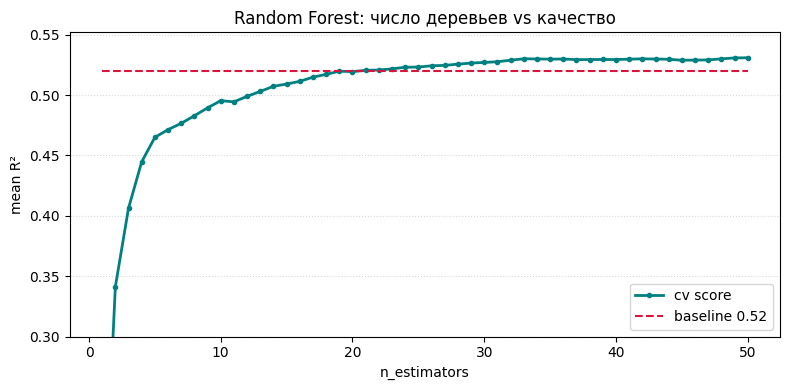

In [23]:
n_trees = np.arange(1, 51)
cv_means = []

for k in n_trees:
    forest = RandomForestRegressor(n_estimators=k, random_state=1, n_jobs=-1)
    r2_vals = cross_val_score(forest, features, target, cv=kfold_splitter, scoring='r2')
    cv_means.append(np.mean(r2_vals))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_trees, cv_means, marker='.', color='teal', linewidth=2)
ax.hlines(y=0.52, xmin=1, xmax=50, colors='crimson', linestyles='dashed', linewidth=1.5)
ax.set_xlabel('n_estimators')
ax.set_ylabel('mean R²')
ax.set_title('Random Forest: число деревьев vs качество')
ax.legend(['cv score', 'baseline 0.52'], loc='lower right')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylim(bottom=0.3)
plt.tight_layout()
plt.show()